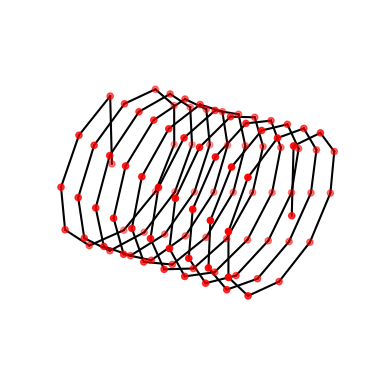

In [1]:
import numpy as np
import dismech

geom = dismech.GeomParams(rod_r0=5e-3,
                          shell_h=0)

material = dismech.Material(density=800,
                            youngs_rod=1e7,
                            youngs_shell=0,
                            poisson_rod=0.5,
                            poisson_shell=0)

static_2d_sim = dismech.SimParams(static_sim=False,
                                  two_d_sim=False,
                                  use_mid_edge=False,
                                  use_line_search=True,
                                  line_search_iters= 2,
                                  show_floor=False,
                                  log_data=True,
                                  log_step=1,
                                  dt=1e-2,
                                  max_iter=50,
                                  total_time=2,
                                  plot_step=1,
                                  tol=1e-4,
                                  ftol=1e-4,
                                  dtol=1e-2
                                  )

env = dismech.Environment()
env.add_force('damping', eta=10)
env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))
# geo = dismech.Geometry.from_txt('../tests/resources/slinky/slinky.txt')
geo = dismech.Geometry.from_txt('../tests/resources/slinky/slinky_top_bottom.txt')
# geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/horizontal_rod_n11.txt')

robot = dismech.SoftRobot(geom, material, geo, static_2d_sim, env)

In [2]:
fixed_points = [0, 1] # fix the first two nodes
end_node_idxs = [robot.n_nodes - 2, robot.n_nodes - 1] # pull the last two nodes
robot = robot.fix_nodes(np.union1d(fixed_points, end_node_idxs))
total_displacement = 0.1
factors = []
def pull(robot, t):
    # slowly increase the displacement of the last node to the right
    factor = min(t/robot.sim_params.total_time, 1.0)
    """ Simple example of a moving boundary condition """
        # [x, y, z]
    u0 = 1
        # [x, y, z]
    robot = robot.move_nodes(end_node_idxs, [u0 * robot.sim_params.dt, 0, 0])
    factors.append(factor)
    
    return robot

stepper = dismech.ImplicitEulerTimeStepper(robot)
stepper.before_step = pull

In [3]:
robots, t_arr, f_norms, Fs = stepper.simulate()

qs = np.stack([robot.state.q for robot in robots])
vs = np.stack([robot.state.u for robot in robots])
t_arr = np.array(t_arr)
Fs_arr = np.array(Fs)
factors.append(1.0) # add the final factor at the end of the simulation

iter: 1, error: 147.606
iter: 2, error: 30.156
iter: 3, error: 24.870
iter: 4, error: 12.097
iter: 5, error: 5.979
iter: 6, error: 2.991
iter: 7, error: 1.506
iter: 8, error: 0.758
iter: 9, error: 0.381
iter: 10, error: 0.191
iter: 11, error: 0.096
iter: 12, error: 0.048
iter: 13, error: 0.024
iter: 14, error: 0.012
current_time:  0.01
iter: 1, error: 159.913
iter: 2, error: 22.417
iter: 3, error: 28.828
iter: 4, error: 14.145
iter: 5, error: 7.005
iter: 6, error: 3.505
iter: 7, error: 1.763
iter: 8, error: 0.887
iter: 9, error: 0.446
iter: 10, error: 0.224
iter: 11, error: 0.112
iter: 12, error: 0.056
iter: 13, error: 0.028
iter: 14, error: 0.014
current_time:  0.02
iter: 1, error: 160.339
iter: 2, error: 20.917
iter: 3, error: 28.311
iter: 4, error: 13.920
iter: 5, error: 6.910
iter: 6, error: 3.463
iter: 7, error: 1.743
iter: 8, error: 0.877
iter: 9, error: 0.441
iter: 10, error: 0.221
iter: 11, error: 0.111
iter: 12, error: 0.055
iter: 13, error: 0.028
iter: 14, error: 0.014
curren

In [4]:
options = dismech.AnimationOptions(title='Helix (N=50)', plot_step=1, camera_view=(0,0))

fig = dismech.get_interactive_animation_plotly(robot, t_arr, qs, options)
fig.show()

201


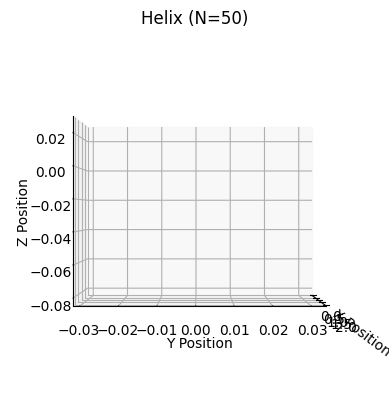

In [5]:
ani = dismech.get_animation(robot, t_arr, qs, options)
ani.save('slinky_pulling.gif')

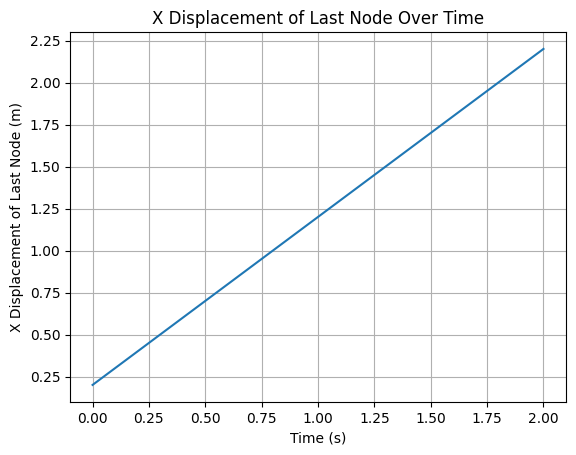

In [6]:
# plot the x discplacement of the last node over time
import matplotlib.pyplot as plt
last_node_x_disp = qs[:, robot.end_node_dof_index-3] # x is the first dof of the last node
plt.plot(t_arr, last_node_x_disp)
plt.xlabel('Time (s)')
plt.ylabel('X Displacement of Last Node (m)')
plt.title('X Displacement of Last Node Over Time')
plt.grid()

In [7]:
print(Fs_arr.shape)
print(qs.shape)

(201, 407)
(201, 407)


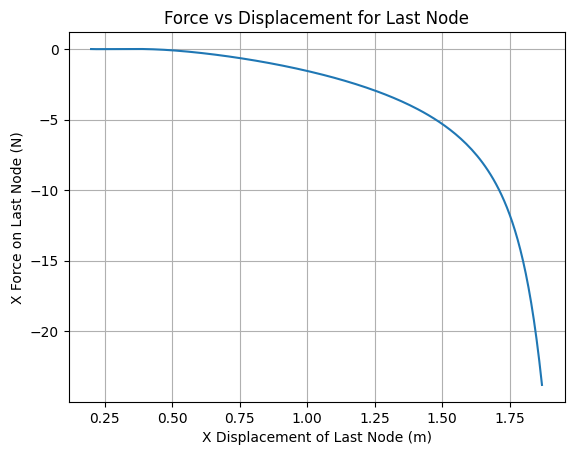

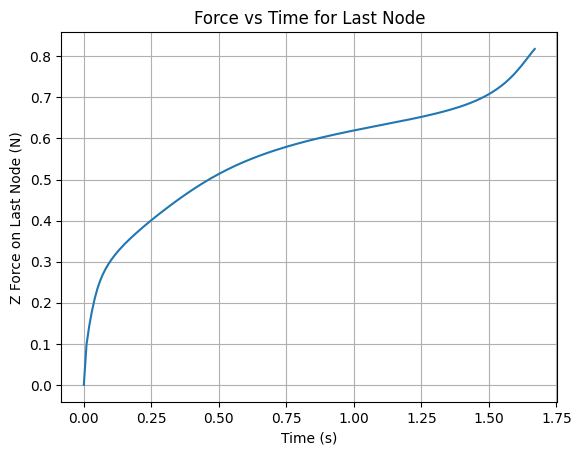

In [10]:
# plot force vs displacement for the last node
last_idx_of_interest = 168 # ignore the last 100 frames where the force goes to zero
# filter all force qs to last_idx_of_interest
q_filtered = qs[:last_idx_of_interest, :]
F_filtered = Fs_arr[:last_idx_of_interest, :]
t_filtered = t_arr[:last_idx_of_interest]

last_node_x_disp = q_filtered[:, robot.end_node_dof_index-3] # x is the first dof of the last node
plt.figure()
plt.plot(last_node_x_disp[:], F_filtered[:, 0]+F_filtered[:, 3]) # x component of the force
plt.xlabel('X Displacement of Last Node (m)')
plt.ylabel('X Force on Last Node (N)')
plt.title('Force vs Displacement for Last Node')
plt.grid()
plt.show()


# last node z force with time
plt.figure()
plt.plot(t_filtered[:], F_filtered[:, 5]) # z component of the force
plt.xlabel('Time (s)')
plt.ylabel('Z Force on Last Node (N)')
plt.title('Force vs Time for Last Node')
plt.grid()
plt.show()

In [9]:
print(t_filtered[168])

IndexError: index 168 is out of bounds for axis 0 with size 168

In [ ]:
import numpy as np

def resample_uniform_time(F, t_array, num_points=10):
    """
    Resample force F(t) onto equally spaced time points.

    Args:
        F:        shape (N,)
        t_array:  shape (N,) (non-uniform time)
        num_points: number of desired samples

    Returns:
        t_uniform: shape (num_points,)
        F_uniform: shape (num_points,)
    """
    # Ensure arrays
    F = np.asarray(F)
    t_array = np.asarray(t_array)

    # Create equally spaced time grid
    t_uniform = np.linspace(t_array.min(), t_array.max(), num_points)

    # Interpolate F onto uniform time grid
    F_uniform = np.interp(t_uniform, t_array, F)

    return t_uniform, F_uniform

In [ ]:
# # data to train 
# num_points = 50

# t_to_train, F_to_train = resample_uniform_time(Fs_arr[:-last_idx_of_interest, 0], useful_t_arr, num_points=num_points)
# print("Resampled time points:", t_to_train)
# print("Resampled force points:", F_to_train)

# plt.plot(t_to_train, F_to_train, 'o-')
# plt.xlabel('Time (s)')
# plt.ylabel('X Force on Last Node (N)')
# plt.title('Resampled Force vs Time for Last Node')
# plt.grid()

In [ ]:
print(robot.end_node_dof_index)

1206


In [ ]:
# the shapes of my qs, Fs are:
# qs: # (num_time_steps, num_dofs)
# Fs: # (num_time_steps, num_dofs)

In [ ]:
import numpy as np

num_t = q_filtered.shape[0]

# original qs format:
# [all node positions, all thetas]
# = [x0,y0,z0, x1,y1,z1, ..., x_{N-1},y_{N-1},z_{N-1}, theta0,...,theta_{N-2}]

# extract all node positions
positions = q_filtered[:, :robot.end_node_dof_index]                    # shape (num_t, 3*N)
positions_reshaped = positions.reshape(num_t, robot.n_nodes, 3)

# first and last nodes
node0 = positions_reshaped[:, 0, :]        # shape (num_t, 3)
node_last = positions_reshaped[:, -1, :]   # shape (num_t, 3)

# centroid of all original nodes
centroid = np.mean(positions_reshaped, axis=1)   # shape (num_t, 3)

# reduced state:
# [x0,y0,z0,theta0, xc,yc,zc,theta1, xlast,ylast,zlast]
qs_to_train = np.zeros((num_t, 11))
qs_to_train[:, 0:3] = node0
qs_to_train[:, 3] = 0.0
qs_to_train[:, 4:7] = centroid
qs_to_train[:, 7] = 0.0
qs_to_train[:, 8:11] = node_last

# BC dofs in reduced state
idx_b = [0, 1, 2, 3, 7, 8, 9, 10]

# BC values over time
xb = np.zeros((num_t, len(idx_b)))
xb[:, 5:8] = node_last

# example force target: x,z force on node 0 with zero y
F_train = np.column_stack([
    F_filtered[:, 0],
    np.zeros(num_t),
    F_filtered[:, 2]
])

# add time (lambdas array) to the training data
lambdas = np.linspace(0, 1, num_t) # shape (num_t,)


In [ ]:
# add a preeceding dimension to all arrays to indicate that we have only one trajectory (can be used for multiple trajectories in the future)
qs_to_train = qs_to_train[np.newaxis, :, :] # shape (1, num_t, 11)
F_train = F_train[np.newaxis, :, :] # shape (1, num_t, 3)
xb = xb[np.newaxis, :, :] # shape (1, num_t, 8)
lambdas = lambdas[np.newaxis, :] # shape (1, num_t)
valid = np.full((qs_to_train.shape[0], qs_to_train.shape[1]), True)

In [ ]:
# initial location of last node x and the final location of the last node x
initial_last_node_x = q_filtered[0, robot.end_node_dof_index-3]
final_last_node_x = q_filtered[-1, robot.end_node_dof_index-3]

print(f"Initial last node x: {initial_last_node_x:.4f} m")
print(f"Final last node x: {final_last_node_x:.4f} m")

# save in .npz format
# np.savez('slinky_2D_train_data_static.npz', qs=qs_to_train, F=F_train, xb=xb, idx_b=idx_b, lambdas=lambdas, valid=valid)

Initial last node x: 0.2000 m
Final last node x: 2.2000 m


In [ ]:
print(qs_to_train.shape)

(1, 480, 11)


In [ ]:
print("total mass:", sum(robot.mass_matrix))

total mass: 0.36824655408316836


In [ ]:
print(valid.shape)

(1, 480)
